In [386]:
import numpy as np
import matplotlib.pyplot as plt

Backwards Time Centered Space Implicit Method

In [387]:
D = 5 # Diffusivity
time_step = 0.01
step_size = 0.10
length = 1

In [388]:
r = (D * time_step) / (step_size**2)
r

4.999999999999999

In [389]:
2 * r + 1

10.999999999999998

In [390]:
n = 1

In [391]:
x_range = np.arange(0, length + step_size, step_size)
t_range = np.arange(0, length + time_step, time_step)

In [392]:
t_range

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  ])

In [393]:
x_len, t_len = len(x_range), len(t_range)

In [394]:
first_diag = np.array([-r] * (x_len - 1))
first_diag.T

array([-5., -5., -5., -5., -5., -5., -5., -5., -5., -5.])

In [395]:
second_diag = np.array([2*r + 1] * x_len)
second_diag.T

array([11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11.])

Build A for Ax = b

In [396]:
A = np.diag(second_diag, k = 0) + np.diag(first_diag, k = -1) + np.diag(first_diag, k = 1)
A

array([[11., -5.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [-5., 11., -5.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0., -5., 11., -5.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0., -5., 11., -5.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0., -5., 11., -5.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0., -5., 11., -5.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0., -5., 11., -5.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., -5., 11., -5.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0., -5., 11., -5.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -5., 11., -5.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -5., 11.]])

In [397]:
A[:, 1:-1]

array([[-5.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [11., -5.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [-5., 11., -5.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0., -5., 11., -5.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0., -5., 11., -5.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0., -5., 11., -5.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0., -5., 11., -5.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0., -5., 11., -5.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., -5., 11., -5.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0., -5., 11.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -5.]])

Build Initial Matrix

In [398]:
grid = np.zeros((x_len, t_len))
grid[:,0] = np.sin(n * np.pi * x_range)
grid[0, :] = 0
grid[-1, :] = 0
grid

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.30901699, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.58778525, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.58778525, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.30901699, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(11, 101))

The logic works like we get our first column, then place it as B and try to solve it until we are done.

Neumann BCs

In [399]:
grid[:, 0]

array([0.        , 0.30901699, 0.58778525, 0.80901699, 0.95105652,
       1.        , 0.95105652, 0.80901699, 0.58778525, 0.30901699,
       0.        ])

In [400]:
for i in range(0, t_len - 1):
    b = grid[1:-1, i]
    x = np.linalg.solve(A[1:-1, 1:-1], b)
   
    # Set x as the new 
    grid[1:-1, i + 1] = x
    
    

In [401]:
grid.shape

(11, 101)

In [402]:
grid.round(7)

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.309017 , 0.2074727, 0.1392962, ..., 0.       , 0.       ,
        0.       ],
       [0.5877853, 0.3946364, 0.2649572, ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.5877853, 0.3946364, 0.2649572, ..., 0.       , 0.       ,
        0.       ],
       [0.309017 , 0.2074727, 0.1392962, ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ]], shape=(11, 101))

In [403]:
matrix = np.zeros((x_len, t_len))

for j in range(t_len):
    for i in range(x_len):
        matrix[i, j] = np.sin(n * x_range[i] * np.pi) * np.exp(-np.pi**2 * D * t_range[j] * (n**2))

np.array(matrix.round(7))

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.309017 , 0.1886543, 0.1151731, ..., 0.       , 0.       ,
        0.       ],
       [0.5877853, 0.3588417, 0.2190722, ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.5877853, 0.3588417, 0.2190722, ..., 0.       , 0.       ,
        0.       ],
       [0.309017 , 0.1886543, 0.1151731, ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ]], shape=(11, 101))

In [404]:
frob_norm = np.linalg.norm(grid - matrix, 'fro')
frob_norm

np.float64(0.35858956936778213)

In [405]:
frob_norm / (grid.shape[0] * grid.shape[1])

np.float64(0.0003227628887198759)

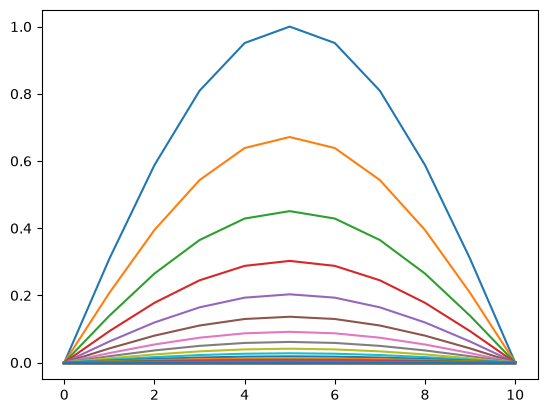

In [406]:
plt.plot(grid)

Plot the matrix as a function of time

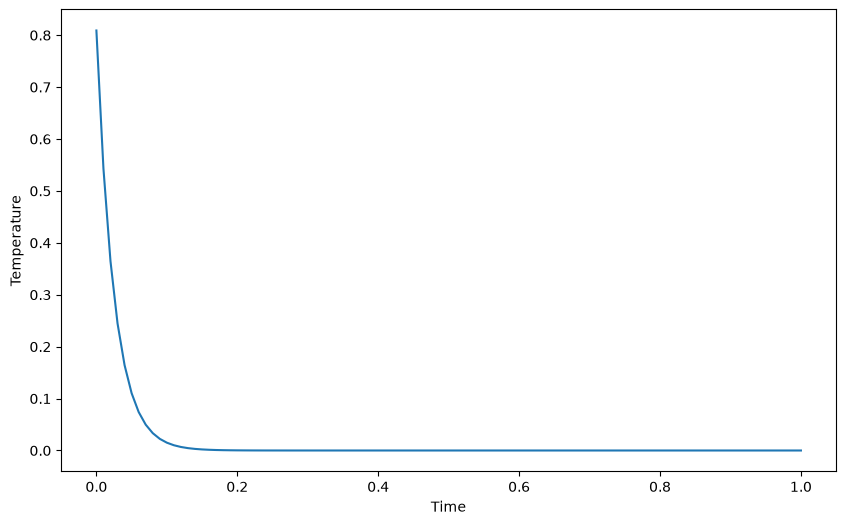

In [407]:
plt.figure(figsize=(10, 6))
plt.plot(t_range, grid[3, :], linewidth=1.5)
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.show()